# Machine Learning Models Implementation

## Objective
This notebook develops and evaluates both a baseline machine learning model and a neural network model for predicting whether a product will be reordered.

The target variable is:

- reordered
    - 1 = Product reordered
    - 0 = Product not reordered

Models Evaluated:
1. Logistic Regression (Baseline)
2. Neural Network (MLPClassifier)

Performance Metrics:
- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

In [1]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

# Baseline Model
from sklearn.linear_model import LogisticRegression

# Neural Network
from sklearn.neural_network import MLPClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
# LOAD DATASET

orders = pd.read_csv("orders.csv")

train = pd.read_csv("order_products__train.csv")

# Merge datasets
df = train.merge(
    orders,
    on="order_id",
    how="left"
)

print(df.head())

print(df.shape)


   order_id  product_id  add_to_cart_order  reordered  user_id eval_set  \
0         1       49302                  1          1   112108    train   
1         1       11109                  2          1   112108    train   
2         1       10246                  3          0   112108    train   
3         1       49683                  4          0   112108    train   
4         1       43633                  5          1   112108    train   

   order_number  order_dow  order_hour_of_day  days_since_prior_order  
0             4          4                 10                     9.0  
1             4          4                 10                     9.0  
2             4          4                 10                     9.0  
3             4          4                 10                     9.0  
4             4          4                 10                     9.0  
(1384617, 10)


In [3]:
# HANDLE MISSING VALUES

df["days_since_prior_order"] = (
    df["days_since_prior_order"]
    .fillna(0)
)

print(df.isnull().sum())

order_id                  0
product_id                0
add_to_cart_order         0
reordered                 0
user_id                   0
eval_set                  0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
dtype: int64


In [4]:
# SELECT FEATURES

features = [
    "add_to_cart_order",
    "order_number",
    "order_dow",
    "order_hour_of_day",
    "days_since_prior_order"
]

X = df[features]

y = df["reordered"]

In [5]:

# SPLIT DATA

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1107693, 5)
(276924, 5)


In [6]:
# FEATURE SCALING

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Baseline Predictive Model

A Logistic Regression classifier is used as the baseline model.

Reasons:
- Easy to implement
- Fast training
- Common benchmark for classification problems
- Provides a performance baseline for comparison with a neural network

In [7]:
# LOGISTIC REGRESSION MODEL

baseline_model = LogisticRegression()

baseline_model.fit(
    X_train,
    y_train
)

baseline_predictions = baseline_model.predict(
    X_test
)

In [8]:
# BASELINE MODEL EVALUATION

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_precision = precision_score(
    y_test,
    baseline_predictions
)

baseline_recall = recall_score(
    y_test,
    baseline_predictions
)

baseline_f1 = f1_score(
    y_test,
    baseline_predictions
)

print("Baseline Accuracy:", baseline_accuracy)
print("Baseline Precision:", baseline_precision)
print("Baseline Recall:", baseline_recall)
print("Baseline F1:", baseline_f1)

print(
    classification_report(
        y_test,
        baseline_predictions
    )
)


Baseline Accuracy: 0.648242839190536
Baseline Precision: 0.6576341026256952
Baseline Recall: 0.8593729249417474
Baseline F1: 0.7450894188949426
              precision    recall  f1-score   support

           0       0.61      0.33      0.43    111266
           1       0.66      0.86      0.75    165658

    accuracy                           0.65    276924
   macro avg       0.64      0.60      0.59    276924
weighted avg       0.64      0.65      0.62    276924



# Neural Network Implementation

Architecture:
- Input Layer: 5 features
- Hidden Layer 1: 32 neurons
- Hidden Layer 2: 16 neurons
- Activation Function: ReLU
- Output Layer: Binary Classification

Reason for Selection:
A multi-layer perceptron can learn nonlinear relationships between customer ordering behavior and product reorder likelihood, potentially outperforming Logistic Regression.

In [9]:
# CREATE NEURAL NETWORK

nn_model = MLPClassifier(

    hidden_layer_sizes=(32,16),

    activation="relu",

    solver="adam",

    max_iter=200,

    random_state=42
)

In [10]:
# TRAIN MODEL

nn_model.fit(
    X_train,
    y_train
)

,hidden_layer_sizes,"(32, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,200
,shuffle,True
,random_state,42


In [11]:
# PREDICTions

nn_predictions = nn_model.predict(
    X_test
)

In [12]:
# PERFORMANCE EVALUATION

nn_accuracy = accuracy_score(
    y_test,
    nn_predictions
)

nn_precision = precision_score(
    y_test,
    nn_predictions
)

nn_recall = recall_score(
    y_test,
    nn_predictions
)

nn_f1 = f1_score(
    y_test,
    nn_predictions
)

print("Neural Network Accuracy:", nn_accuracy)
print("Neural Network Precision:", nn_precision)
print("Neural Network Recall:", nn_recall)
print("Neural Network F1:", nn_f1)

print(
    classification_report(
        y_test,
        nn_predictions
    )
)

Neural Network Accuracy: 0.6609502968323439
Neural Network Precision: 0.6830725433275342
Neural Network Recall: 0.808213306933562
Neural Network F1: 0.7403923520384886
              precision    recall  f1-score   support

           0       0.61      0.44      0.51    111266
           1       0.68      0.81      0.74    165658

    accuracy                           0.66    276924
   macro avg       0.65      0.62      0.63    276924
weighted avg       0.65      0.66      0.65    276924



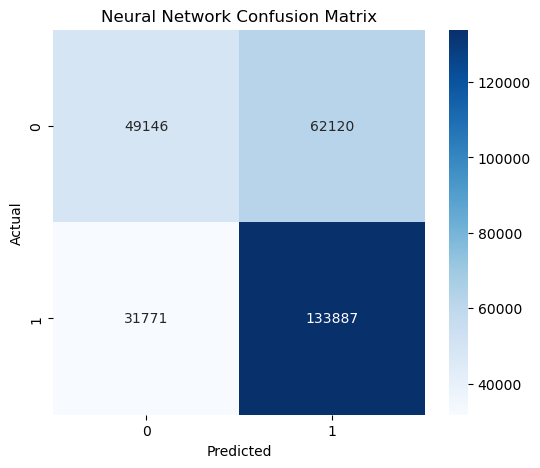

In [13]:
# CONFUSION MATRIX

cm = confusion_matrix(
    y_test,
    nn_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Neural Network Confusion Matrix"
)

plt.ylabel("Actual")

plt.xlabel("Predicted")

plt.show()

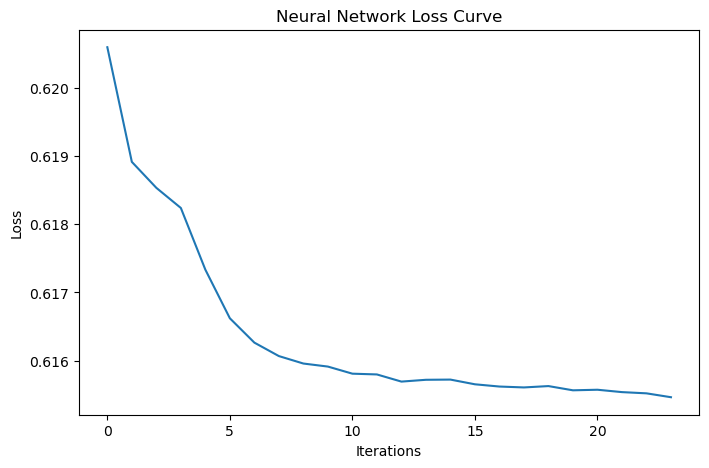

In [14]:
# TRAINING LOSS CURVE

plt.figure(figsize=(8,5))

plt.plot(
    nn_model.loss_curve_
)

plt.title(
    "Neural Network Loss Curve"
)

plt.xlabel("Iterations")

plt.ylabel("Loss")

plt.show()